<a href="https://colab.research.google.com/github/AndresMontesDeOca/GdP/blob/master/Ploteos_Presentacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd


def logistic_cdf(score, loc, scale, max_val):
    return max_val / (1 + np.exp(-(score - loc) / scale))


# 1. Generar vector de scores de 0 a 1000
scores = np.arange(0, 1001)

# 2. Modelar las curvas CDF (Malos asintotan en ~96%, Buenos en ~91% según gráfico)
# Ajustamos los parámetros para que la máxima diferencia caiga en 535
cdf_malos = logistic_cdf(scores, loc=380, scale=85, max_val=0.96)
cdf_buenos = logistic_cdf(scores, loc=660, scale=90, max_val=0.91)

# 3. Crear el DataFrame
df_ks = pd.DataFrame(
    {"score": scores, "cdf_malos": cdf_malos, "cdf_buenos": cdf_buenos}
)

# 4. Calcular la distancia y validar el KS Máximo
df_ks["distancia"] = df_ks["cdf_malos"] - df_ks["cdf_buenos"]
ks_max_row = df_ks.loc[df_ks["distancia"].idxmax()]

print(f"KS Máximo teórico encontrado en Score: {int(ks_max_row['score'])}")
print(f"Valor del KS (Diferencia Máxima): {int(round(ks_max_row['distancia'] * 100))}%")

KS Máximo teórico encontrado en Score: 523
Valor del KS (Diferencia Máxima): 65%


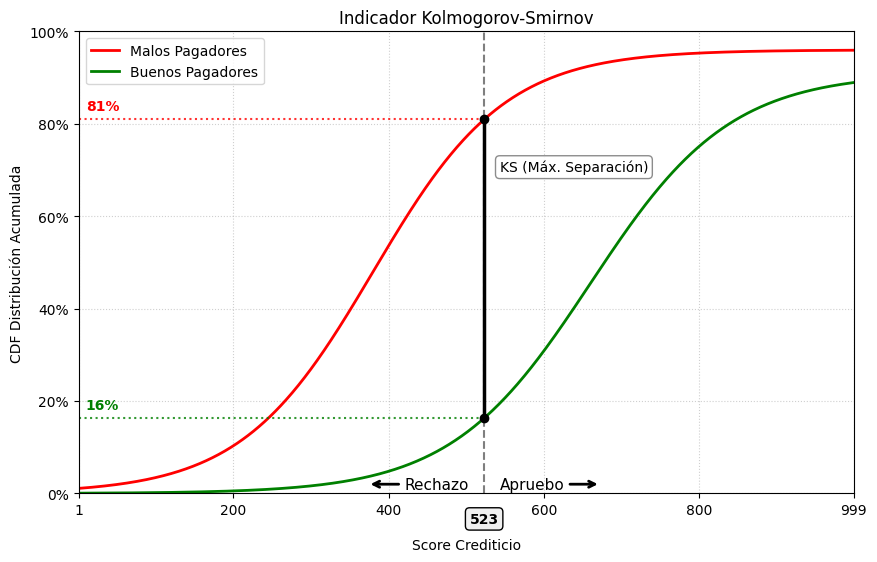

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_ks["score"], df_ks["cdf_malos"], color="red", label="Malos Pagadores", linewidth=2)
plt.plot(df_ks["score"], df_ks["cdf_buenos"], color="green", label="Buenos Pagadores", linewidth=2)

# Línea del KS Máximo
score_ks = int(ks_max_row["score"])
ks_malos = ks_max_row["cdf_malos"]
ks_buenos = ks_max_row["cdf_buenos"]

# Quitamos el label para que no aparezca en la leyenda
plt.axvline(x=score_ks, color="black", linestyle="--", alpha=0.5)

# Puntos de intersección y línea de distancia KS
plt.scatter([score_ks, score_ks], [ks_malos, ks_buenos], color="black", zorder=5)
plt.plot([score_ks, score_ks], [ks_buenos, ks_malos], color="black", linestyle="-", linewidth=2.5)

# Etiqueta de la separación máxima (desplazada hacia arriba)
plt.text(score_ks + 20, (ks_malos + ks_buenos) / 2 + 0.22, "KS (Máx. Separación)",
         color="black", fontsize=10, va="center",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

# Proyecciones al eje Y
plt.hlines(y=ks_malos, xmin=1, xmax=score_ks, color="red", linestyle=":", alpha=0.8, linewidth=1.5)
plt.hlines(y=ks_buenos, xmin=1, xmax=score_ks, color="green", linestyle=":", alpha=0.8, linewidth=1.5)

# --- NUEVO: Flechas de Apruebo y Rechazo ---
y_arrows = 0.02 # Altura para las flechas en el eje Y (más abajo)

# Flecha Rechazo (Hacia la izquierda, en negro)
plt.annotate("Rechazo", xy=(score_ks - 150, y_arrows), xytext=(score_ks - 20, y_arrows),
             arrowprops=dict(arrowstyle="->", color="black", lw=2),
             color="black", fontsize=11, va="center", ha="right")

# Flecha Apruebo (Hacia la derecha, en negro)
plt.annotate("Apruebo", xy=(score_ks + 150, y_arrows), xytext=(score_ks + 20, y_arrows),
             arrowprops=dict(arrowstyle="->", color="black", lw=2),
             color="black", fontsize=11, va="center", ha="left")

plt.title("Indicador Kolmogorov-Smirnov")
plt.xlabel("Score Crediticio", labelpad=15)
plt.ylabel("CDF Distribución Acumulada")
plt.xlim(1, 999)
plt.ylim(0, 1)
plt.xticks([1, 200, 400, 600, 800, 999])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y*100)}%"))

# Etiquetas sobre las proyecciones en el eje Y (Corregido a round)
plt.text(10, ks_malos + 0.02, f"{int(round(ks_malos*100))}%", color="red", fontsize=10, fontweight="bold")
plt.text(10, ks_buenos + 0.02, f"{int(round(ks_buenos*100))}%", color="green", fontsize=10, fontweight="bold")

# Etiqueta resaltada en el eje X para el Score
plt.text(score_ks, -0.04, f"{score_ks}", color="black", fontsize=10, fontweight="bold",
         ha="center", va="top", bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0", ec="black", alpha=1), clip_on=False)

plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()